# Match test ($e_0$ Vs ${\cal M}^*_\%$)

In [1]:
import os
from pycbc.filter.matchedfilter import match
from pycbc.types.frequencyseries import FrequencySeries
import numpy as np
import bilby
import matplotlib.pyplot as plt
from tqdm import tqdm
%matplotlib inline

C = 299792458.
G = 6.67408*1e-11
Mo = 1.989*1e30
Mpc = 3.086*1e22

/Users/phurailatpamhemantakumar/anaconda3/envs/ler/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/Users/phurailatpamhemantakumar/anaconda3/envs/ler/lib/python3.10/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this p

In [2]:
Gamma = 0.5772156649015329
Pi = np.pi
MTSUN_SI = 4.925491025543576e-06

def findchirp_chirptime(m1, m2, fmin):
    """
    Time taken from f_min to f_lso (last stable orbit). 3.5PN in fourier phase considered.

    Parameters
    ----------
    m1 : `float`
        Mass of the first body in solar masses.
    m2 : `float`
        Mass of the second body in solar masses.
    fmin : `float`
        Lower frequency cutoff.

    Returns
    -------
    chirp_time : float
        Time taken from f_min to f_lso (last stable orbit frequency).
    """

    # variables used to compute chirp time
    m = m1 + m2
    eta = m1 * m2 / m / m
    c0T = c2T = c3T = c4T = c5T = c6T = c6LogT = c7T = 0.0

    c7T = Pi * (
        14809.0 * eta * eta / 378.0 - 75703.0 * eta / 756.0 - 15419335.0 / 127008.0
    )

    c6T = (
        Gamma * 6848.0 / 105.0
        - 10052469856691.0 / 23471078400.0
        + Pi * Pi * 128.0 / 3.0
        + eta * (3147553127.0 / 3048192.0 - Pi * Pi * 451.0 / 12.0)
        - eta * eta * 15211.0 / 1728.0
        + eta * eta * eta * 25565.0 / 1296.0
        + eta * eta * eta * 25565.0 / 1296.0
        + np.log(4.0) * 6848.0 / 105.0
    )
    c6LogT = 6848.0 / 105.0

    c5T = 13.0 * Pi * eta / 3.0 - 7729.0 * Pi / 252.0

    c4T = 3058673.0 / 508032.0 + eta * (5429.0 / 504.0 + eta * 617.0 / 72.0)
    c3T = -32.0 * Pi / 5.0
    c2T = 743.0 / 252.0 + eta * 11.0 / 3.0
    c0T = 5.0 * m * MTSUN_SI / (256.0 * eta)

    # This is the PN parameter v evaluated at the lower freq. cutoff
    xT = np.power(Pi * m * MTSUN_SI * fmin, 1.0 / 3.0)
    x2T = xT * xT
    x3T = xT * x2T
    x4T = x2T * x2T
    x5T = x2T * x3T
    x6T = x3T * x3T
    x7T = x3T * x4T
    x8T = x4T * x4T

    # Computes the chirp time as tC = t(v_low)
    # tC = t(v_low) - t(v_upper) would be more
    # correct, but the difference is negligble.
    return (
        c0T
        * (
            1
            + c2T * x2T
            + c3T * x3T
            + c4T * x4T
            + c5T * x5T
            + (c6T + c6LogT * np.log(xT)) * x6T
            + c7T * x7T
        )
        / x8T
    )

In [3]:
time_of_event = 1126259642.413
post_trigger_duration = 1.
duration = 309.0
analysis_start = time_of_event + post_trigger_duration - duration
sampling_frequency = 4096.
f_min = 20.0

injection_parameters = {'mass_1':1.61, 'mass_2':1.18, 'eccentricity':0.1, 'a_1':0., 'a_2':0., 'tilt_1':0., 'tilt_2':0., 'phi_12':0., 'phi_jl':0., 'luminosity_distance':38.87, 'theta_jn':0.4, 'psi':2.659, 'phase':1.3, 'geocent_time':1126259642.413, 'ra':1.375, 'dec':-1.2108,}

In [4]:
############# TF2Ecck waveform model ################
waveform_arguments1 = dict(waveform_approximant='TaylorF2Ecck',
                          reference_frequency=f_min, minimum_frequency=f_min)

waveform_generator1 = bilby.gw.WaveformGenerator(
    duration=duration, sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_eccentric_binary_black_hole_no_spins,
    parameters=injection_parameters, waveform_arguments=waveform_arguments1)

############# TF2Ecch waveform model ################
waveform_arguments2 = dict(waveform_approximant='TaylorF2Ecch',
                          reference_frequency=f_min, minimum_frequency=f_min)

waveform_generator2 = bilby.gw.WaveformGenerator(
    duration=duration, sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_eccentric_binary_black_hole_no_spins,
    parameters=injection_parameters, waveform_arguments=waveform_arguments2)

############# TF2Ecc waveform model ################
waveform_arguments3 = dict(waveform_approximant='TaylorF2Ecc',
                          reference_frequency=f_min, minimum_frequency=f_min, pn_phase_order=6, pn_tidal_order=0)

waveform_generator3 = bilby.gw.WaveformGenerator(
    duration=duration, sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_eccentric_binary_black_hole_no_spins,
    parameters=injection_parameters, waveform_arguments=waveform_arguments3)

############# TaylorF2 waveform model ################
waveform_arguments4 = dict(waveform_approximant='TaylorF2',
                          reference_frequency=f_min, minimum_frequency=f_min, pn_phase_order=6, pn_amplitude_order=0, pn_tidal_order=0)

waveform_generator4 = bilby.gw.WaveformGenerator(
    duration=duration, sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_eccentric_binary_black_hole_no_spins,
    parameters=injection_parameters, waveform_arguments=waveform_arguments4)

ifos = bilby.gw.detector.InterferometerList(['L1'])
ifos.set_strain_data_from_zero_noise(
    sampling_frequency=sampling_frequency, duration=duration,
    start_time=analysis_start)

05:49 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_eccentric_binary_black_hole_no_spins
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
05:49 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_eccentric_binary_black_hole_no_spins
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
05:49 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_eccentric_binary_black_hole_no_spins
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
05:49 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_eccentric_binary_black_hole_no_spins
  time_domain_source_model: None
  parameter_conversi

In [5]:
from gwsnr import GWSNR

gwsnr = GWSNR(
    snr_method='inner_product',
    gwsnr_verbose=False,
    ifos=['L1', 'H1'],
    multiprocessing_verbose=False,
    waveform_approximant='TaylorF2',
)

Extracting interpolator data from /Users/phurailatpamhemantakumar/phd/mypackages/gwsnr/gwsnr/core/core_data/interpolator_json.zip to the current working directory.

Initializing GWSNR class...





In [6]:
gwsnr.optimal_snr_with_inner_product(gw_param_dict=injection_parameters)
# 40

{'optimal_snr_L1': array([40.45965382]),
 'optimal_snr_H1': array([49.96981144]),
 'optimal_snr_net': array([64.29592244])}

In [7]:
# size1 = 10
# mass_1 = np.random.uniform(1.0, 3.0, size1)
# mass_2 = np.random.uniform(1.0, 3.0, size1)
# # swap if mass_1 < mass_2
# idx_ = mass_1 < mass_2
# mass_1[idx_], mass_2[idx_] = mass_2[idx_], mass_1[idx_]

size2 = 20 # number of eccentricity values
eccn_array = np.linspace(0.0,0.26,size2)

## TaylorrF2Ecck vs TaylorF2Ecch

In [8]:
from tqdm import tqdm

resume = True
if not resume:
    # remove the file
    os.remove('match_array_12.npy')

if not os.path.exists('match_array_12.npy'):
    print('match_array_12.npy does not exist')
    match_array_12 = []

    mass_1_ = 1.61
    mass_2_ = 1.18
    #f_max = 128.
    f_max = (C**3)/( G*(mass_1_+mass_2_)*Mo*np.pi*6**(3/2) )

    safety = 1.2
    approx_duration = safety * findchirp_chirptime(mass_1_, mass_2_, f_min)
    duration = np.ceil(approx_duration + 2.0)

    match_array_list = []
    for eccn in tqdm(eccn_array, desc="e0 (Ecck vs Ecch)"):

        injection_parameters['eccentricity'] = eccn

        polas_a = waveform_generator1.frequency_domain_strain(parameters = injection_parameters) # TF2Ecck
        polas_b = waveform_generator2.frequency_domain_strain(parameters = injection_parameters) # TF2Ecch
        arr_a = FrequencySeries(polas_a['plus'], delta_f=1/duration)
        arr_b = FrequencySeries(polas_b['plus'], delta_f=1/duration)
        psd_ = FrequencySeries(ifos[0].power_spectral_density_array, delta_f=1/duration)

        
        match_array_list.append(match(arr_a, arr_b, psd=psd_, low_frequency_cutoff=f_min, high_frequency_cutoff=f_max)[0])

    # save data
    match_array_12 = np.array(match_array_list)
    np.save('match_array_12.npy', match_array_12)
else:
    print('match_array_12.npy exists')
    match_array_12 = np.load('match_array_12.npy')

match_array_12.npy exists


In [9]:
match_array_12

array([1.        , 0.99978588, 0.99914563, 0.99807696,
       0.99659539, 0.99469218, 0.99235594, 0.9896601 ,
       0.9864881 , 0.98302063, 0.97905773, 0.97473112,
       0.97020768, 0.96521578, 0.95989539, 0.95410243,
       0.9480829 , 0.94171286, 0.93516117, 0.92851316])

## TaylorrF2Ecck vs TaylorF2Ecc

In [10]:
from tqdm import tqdm

resume = True
if not resume:
    # remove the file
    if os.path.exists('match_array_13.npy'):
        os.remove('match_array_13.npy')

if not os.path.exists('match_array_13.npy'):
    print('match_array_13.npy does not exist')
    match_array_13 = []

    mass_1_ = 1.61
    mass_2_ = 1.18
    #f_max = 128.
    f_max = (C**3)/( G*(mass_1_+mass_2_)*Mo*np.pi*6**(3/2) )

    safety = 1.2
    approx_duration = safety * findchirp_chirptime(mass_1_, mass_2_, f_min)
    duration = np.ceil(approx_duration + 2.0)

    match_array_list = []
    for eccn in tqdm(eccn_array, desc="e0 (Ecck vs Ecc)"):

        injection_parameters['eccentricity'] = eccn
        
        polas_a = waveform_generator1.frequency_domain_strain(parameters = injection_parameters) # TF2Ecck
        polas_b = waveform_generator3.frequency_domain_strain(parameters = injection_parameters) # TF2Ecc
        arr_a = FrequencySeries(polas_a['plus'], delta_f=1/duration)
        arr_b = FrequencySeries(polas_b['plus'], delta_f=1/duration)
        psd_ = FrequencySeries(ifos[0].power_spectral_density_array, delta_f=1/duration)

        
        match_array_list.append(match(arr_a, arr_b, psd=psd_, low_frequency_cutoff=f_min, high_frequency_cutoff=f_max)[0])

    # save data
    match_array_13 = np.array(match_array_list)
    np.save('match_array_13.npy', match_array_13)
else:
    print('match_array_13.npy exists')
    match_array_13 = np.load('match_array_13.npy')

match_array_13.npy exists


In [11]:
match_array_13

array([1.        , 0.99989313, 0.99957284, 0.99904264,
       0.99829605, 0.99734066, 0.99618469, 0.9948083 ,
       0.99324301, 0.99145533, 0.98950866, 0.98732828,
       0.984967  , 0.98245479, 0.97971917, 0.97681487,
       0.97372026, 0.97048892, 0.96709153, 0.96356716])

## TaylorrF2Ecck vs TaylorF2

In [12]:
from tqdm import tqdm

eccn_array_ = np.linspace(0.0001,0.02,10)

resume = True
if not resume:
    # remove the file
    if os.path.exists('match_array_14.npy'):
        os.remove('match_array_14.npy')

if not os.path.exists('match_array_14.npy'):
    print('match_array_14.npy does not exist')
    match_array_14 = []

    mass_1_ = 1.61
    mass_2_ = 1.18
    #f_max = 128.
    f_max = (C**3)/( G*(mass_1_+mass_2_)*Mo*np.pi*6**(3/2) )

    safety = 1.2
    approx_duration = safety * findchirp_chirptime(mass_1_, mass_2_, f_min)
    duration = np.ceil(approx_duration + 2.0)

    match_array_list = []
    for eccn in tqdm(eccn_array_, desc="e0 (Ecck vs Ecc)"):

        injection_parameters['eccentricity'] = eccn
        
        polas_a = waveform_generator1.frequency_domain_strain(parameters = injection_parameters) # TF2Ecck
        polas_b = waveform_generator4.frequency_domain_strain(parameters = injection_parameters) # TF2Ecc
        arr_a = FrequencySeries(polas_a['plus'], delta_f=1/duration)
        arr_b = FrequencySeries(polas_b['plus'], delta_f=1/duration)
        psd_ = FrequencySeries(ifos[0].power_spectral_density_array, delta_f=1/duration)

        
        match_array_list.append(match(arr_a, arr_b, psd=psd_, low_frequency_cutoff=f_min, high_frequency_cutoff=f_max)[0])

    # save data
    match_array_14 = np.array(match_array_list)
    np.save('match_array_14.npy', match_array_14)
else:
    print('match_array_14.npy exists')
    match_array_14 = np.load('match_array_14.npy')

match_array_14.npy exists


In [13]:
match_array_14

array([0.99999999, 0.99991772, 0.99883158, 0.99437003,
       0.98314287, 0.9622465 , 0.93467611, 0.90351787,
       0.87382282, 0.84846847])

## Plot

e0 at M*_%% = 0.03 (Ecck vs Ecch): 0.01621021494633046
e0 at M*_%% = 0.03 (Ecck vs Ecc):  0.022918139067389976
e0 at M*_%% = 0.03 (Ecck vs TF2):  0.0032277249411018366
e0 at M*_%% = 0.3 (Ecck vs Ecch): 0.05135173654824802
e0 at M*_%% = 0.3 (Ecck vs Ecc):  0.07272475540680343
e0 at M*_%% = 0.3 (Ecck vs TF2):  0.005732459288697005


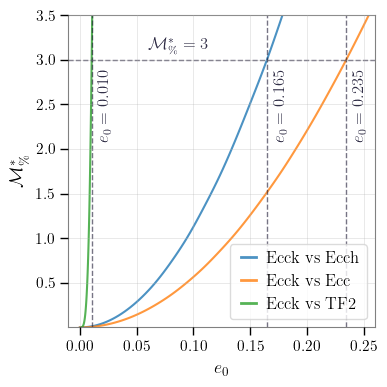

In [14]:
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq

size1 = 100
size2 = 20

# Reference mismatch % for horizontal rule and for e0 intercepts on the splines
MSTAR_REF = 3.0
size_axis_label = 13
size_tick_label = 11
size_legend_label = 12

# Setup the figure
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": size_tick_label
})
plt.figure(figsize=(4., 4.))

# First plot (mismatch percentage). Ensure curves start at (e0, M*) = (0, 0).
def _prepend_zero_e0(x_grid, mismatch_pct):
    """
    If e0 grid already starts at 0, force the first mismatch point to 0 only.
    Otherwise prepend (0, 0) so the line originates from circular orbit.
    Works for 1d (single curve) or 2d (many mass samples vs e0).
    """
    x_grid = np.asarray(x_grid, dtype=float)
    mm = np.asarray(mismatch_pct, dtype=float)
    if x_grid.size and np.isclose(x_grid[0], 0.0):
        y_out = mm.copy()
        if y_out.ndim == 1:
            y_out[0] = 0.0
        else:
            y_out[:, 0] = 0.0
        return x_grid, y_out
    x_out = np.concatenate([[0.0], x_grid])
    if mm.ndim == 1:
        y_out = np.concatenate([[0.0], mm])
    else:
        y_out = np.hstack([np.zeros((mm.shape[0], 1)), mm])
    return x_out, y_out


def _median_along_mass(y):
    """Collapse (n_mass, n_e0) -> (n_e0,) for spline fitting; keep 1d as-is."""
    y = np.asarray(y, dtype=float)
    if y.ndim == 2:
        return np.nanmedian(y, axis=0)
    return y


def _e0_at_mismatch_level(interp, x_knots, level=MSTAR_REF, x_extrap_max=0.26):
    """
    e0 where the cubic spline equals ``level`` (mismatch %).
    If the curve is still below ``level`` at the last knot, search up to
    ``x_extrap_max`` (splines use extrapolate=True).
    """
    x_lo = float(np.min(x_knots))
    x_hi = float(np.max(x_knots))
    x_max = float(max(x_hi, x_extrap_max))

    def delta(x):
        v = interp(x)
        v = float(np.median(v)) if isinstance(v, np.ndarray) and v.ndim > 0 else float(v)
        return v - level

    d_lo = delta(x_lo)
    d_hi = delta(x_hi)
    if d_lo >= 0:
        return x_lo
    if d_hi >= 0:
        return brentq(delta, x_lo, x_hi)
    d_max = delta(x_max)
    if d_max < 0:
        return np.nan
    return brentq(delta, x_hi, x_max)


# --- spline curves: same knot pre-processing for (0, 0), median across masses if 2d ---
x_knots_12, y_raw = _prepend_zero_e0(eccn_array, np.nan_to_num((1 - match_array_12) * 100))
y_1d = _median_along_mass(y_raw)
interp12 = CubicSpline(x_knots_12, y_1d, extrapolate=True)
x_plot = np.linspace(0, 0.26, 100)
plt.plot(x_plot, interp12(x_plot), 'C0', alpha=0.8, linewidth=1.5)
e0_12 = _e0_at_mismatch_level(interp12, x_knots_12)

_, y_raw = _prepend_zero_e0(eccn_array, np.nan_to_num((1 - match_array_13) * 100))
y_1d = _median_along_mass(y_raw)
interp13 = CubicSpline(x_knots_12, y_1d, extrapolate=True)
plt.plot(x_plot, interp13(x_plot), 'C1', alpha=0.8, linewidth=1.5)
e0_13 = _e0_at_mismatch_level(interp13, x_knots_12)

x_knots_14, y_raw = _prepend_zero_e0(eccn_array_, np.nan_to_num((1 - match_array_14) * 100))
y_1d = _median_along_mass(y_raw)
interp14 = CubicSpline(x_knots_14, y_1d, extrapolate=True)
x_plot_tf2 = np.linspace(0.001, 0.02, 100)
plt.plot(x_plot_tf2, interp14(x_plot_tf2), 'C2', alpha=0.8, linewidth=1.5)
e0_14 = _e0_at_mismatch_level(interp14, x_knots_14)

# e0 where M*_%% = 0.03 (same units as y-axis: (1-match)*100). Print only — not drawn.
MSTAR_LOW = 0.03
_xmax_interp = 0.26
_e0_12_lo = _e0_at_mismatch_level(
    interp12, x_knots_12, level=MSTAR_LOW, x_extrap_max=_xmax_interp
)
_e0_13_lo = _e0_at_mismatch_level(
    interp13, x_knots_12, level=MSTAR_LOW, x_extrap_max=_xmax_interp
)
_e0_14_lo = _e0_at_mismatch_level(
    interp14, x_knots_14, level=MSTAR_LOW, x_extrap_max=_xmax_interp
)
print(f'e0 at M*_%% = {MSTAR_LOW} (Ecck vs Ecch): {_e0_12_lo}')
print(f'e0 at M*_%% = {MSTAR_LOW} (Ecck vs Ecc):  {_e0_13_lo}')
print(f'e0 at M*_%% = {MSTAR_LOW} (Ecck vs TF2):  {_e0_14_lo}')

# e0 where M*_%% = 0.3 (same y-axis units). Print only — not drawn.
MSTAR_MID = 0.3
_e0_12_mid = _e0_at_mismatch_level(
    interp12, x_knots_12, level=MSTAR_MID, x_extrap_max=_xmax_interp
)
_e0_13_mid = _e0_at_mismatch_level(
    interp13, x_knots_12, level=MSTAR_MID, x_extrap_max=_xmax_interp
)
_e0_14_mid = _e0_at_mismatch_level(
    interp14, x_knots_14, level=MSTAR_MID, x_extrap_max=_xmax_interp
)
print(f'e0 at M*_%% = {MSTAR_MID} (Ecck vs Ecch): {_e0_12_mid}')
print(f'e0 at M*_%% = {MSTAR_MID} (Ecck vs Ecc):  {_e0_13_mid}')
print(f'e0 at M*_%% = {MSTAR_MID} (Ecck vs TF2):  {_e0_14_mid}')

# Labeling the first plot
plt.xlabel(r"$e_0$", fontdict={'fontsize': size_axis_label})
plt.ylabel(r"${\cal M}^*_{\%}$", fontdict={'fontsize': size_axis_label})
plt.tick_params(axis='both', which='both', labelsize=size_tick_label)

legend = plt.legend(['Ecck vs Ecch', 'Ecck vs Ecc', 'Ecck vs TF2'], handlelength=1.5, loc='lower right', bbox_to_anchor=(1.0, 0.0), frameon=True, fontsize=size_legend_label, edgecolor='lightgray')
legend.get_frame().set_boxstyle('Round', pad=0.0, rounding_size=0.2)
# Modify line width for legend entries
for handle in legend.get_lines():
    handle.set_linewidth(2)
    handle.set_alpha(0.8)

plt.xlim(-0.01, 0.26)
plt.ylim(0.001, 3.5)
plt.axhline(y=MSTAR_REF, color='#1B1833', linestyle='--', linewidth=1, alpha=0.6)
plt.text(0.06, 3.12, r'${\cal M}^*_{\%}=3$', color='#1B1833', fontsize=size_legend_label, alpha=0.9)

for e0 in (e0_12, e0_13, e0_14):
    if np.isfinite(e0):
        plt.axvline(x=e0, color='#1B1833', linestyle='--', linewidth=1, alpha=0.6)
        plt.text(e0 + 0.005, 2.1, rf'$e_0={e0:.3f}$', color='#1B1833', fontsize=size_legend_label, alpha=0.9, rotation=90)

# Show the combined plot
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('./mismatch_vs_eccn.pdf')
plt.show()